<a href="https://colab.research.google.com/github/juliacporto-creator/Estatistica-/blob/main/tarefa07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Júlia Porto - 17901372

Larissa Mei - 17903839

Marianne Adorno - 17995367


Grupos 3: Relação entre sólidos solúveis e açúcar estimado
1. Existe uma relação entre o teor de sólidos solúveis e o teor de açúcar estimado
nas amostras?
2. Como o açúcar estimado tende a se comportar quando o teor de sólidos solúveis
aumenta?
3. Quantifique a relação observada entre as duas características e avalie se existem
evidências estatísticas dessa relação.
4. Qual seria o teor de açúcar estimado para uma amostra com 20 °Brix?
5. O teor de sólidos solúveis fornece informações úteis para estimar o teor de
açúcar das amostras? Justifique sua resposta.

In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/fisico-quimicas.csv')

# Display the first 5 rows of the DataFrame
display(df)

,Amostra,Categoria,Solidos_Soluveis_Brix,Acucar_g_100g,pH,Acidez_g_100mL,Acucar_estimado
0,A27,Frutas,14.12,9.42,2.86,0.65,8.706996
1,A05,Sucos e bebidas,10.02,7.17,2.83,0.79,5.552567
2,A60,Néctares e polpas,13.41,5.10,3.03,0.88,8.160741
3,A41,Néctares e polpas,23.37,15.14,2.90,0.45,15.823696
4,A10,Sucos e bebidas,7.71,5.05,2.99,0.79,3.775315
5,A03,Sucos e bebidas,10.94,4.91,3.14,0.88,6.260390
6,A40,Frutas,13.67,8.24,3.01,0.81,8.360778
7,A59,Néctares e polpas,14.28,7.41,2.91,0.74,8.830096
8,A31,Frutas,19.31,13.48,3.23,0.45,12.700042
9,A01,Sucos e bebidas,8.34,3.59,3.10,0.84,4.260020


In [2]:
# Display information about the DataFrame, including column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Amostra                60 non-null     object 
 1   Categoria              60 non-null     object 
 2   Solidos_Soluveis_Brix  60 non-null     float64
 3   Acucar_g_100g          60 non-null     float64
 4   pH                     60 non-null     float64
 5   Acidez_g_100mL         60 non-null     float64
 6   Acucar_estimado        60 non-null     float64
dtypes: float64(5), object(2)
memory usage: 3.4+ KB


                            OLS Regression Results                            
Dep. Variable:        Acucar_estimado   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.200e+30
Date:                Mon, 24 Aug 2026   Prob (F-statistic):               0.00
Time:                        23:45:12   Log-Likelihood:                 1815.4
No. Observations:                  60   AIC:                            -3627.
Df Residuals:                      58   BIC:                            -3623.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -2.15

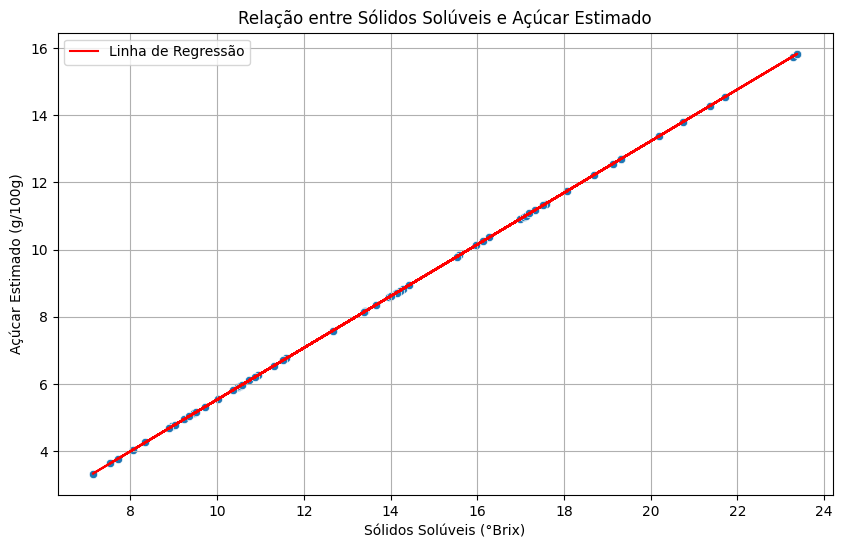

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Define the explanatory and response variables
X = df['Solidos_Soluveis_Brix']
y = df['Acucar_estimado']

# Add a constant to the explanatory variable for statistical modeling
X = sm.add_constant(X)

# Fit the OLS (Ordinary Least Squares) linear regression model
model = sm.OLS(y, X).fit()

# Print the model summary
print(model.summary())

# Plot the relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Solidos_Soluveis_Brix', y='Acucar_estimado', data=df)
plt.plot(df['Solidos_Soluveis_Brix'], model.predict(X), color='red', label='Linha de Regressão')
plt.title('Relação entre Sólidos Solúveis e Açúcar Estimado')
plt.xlabel('Sólidos Solúveis (°Brix)')
plt.ylabel('Açúcar Estimado (g/100g)')
plt.legend()
plt.grid(True)
plt.show()

##Existe uma relação entre o teor de sólidos solúveis e o teor de açúcar estimado nas amostras?

Sim, existe uma relação extremamente forte e positiva entre o teor de sólidos solúveis (°Brix) e o teor de açúcar estimado (g/100g). O coeficiente de determinação (R-squared/Correlação Linear de Pearson) é de 1, o que indica que à medida que a quantiade de sólidos solúveis aumenta, o teor de açúcar estimado também aumenta de forma consistente, sugerindo uma dependência linear quase perfeita.

##Como o açúcar estimado tende a se comportar quando o teor de sólidos solúveis aumenta?

O açúcar estimado é diretamente proporcional ao teor de sólidos solúveis, dessa forma o teor de açúcar estimado tende a aumentar proporcionalmente quando o teor de sólidos solúveis aumenta. O coeficiente para Solidos Soluveis é de aproximadamente 0.7694. Isso significa que, para cada aumento de 1 grau °Brix nos sólidos solúveis, o açúcar estimado aumenta em cerca de 0.7694 g/100g.

##Quantifique a relação observada entre as duas características e avalie se existem evidências estatísticas dessa relação.

A relação entre o teor de sólidos solúveis (°Brix) e o teor de açúcar estimado (g/100g) é quantificada através de uma equação de regressão linear. Essa equação permite prever o valor do açúcar estimado com base no valor dos sólidos solúveis.

Açúcar Estimado = -2.1566 + 0.7694 * Sólidos Solúveis (°Brix)

O valor -2.1566 é o intercepto, que representa o valor estimado do açúcar quando os sólidos solúveis são zero. Embora matematicamente relevante para a linha de regressão, na prática, um teor de sólidos solúveis de zero não ocorre em produtos com açúcar.

O valor 0.7694 é o coeficiente angular para Solidos Soluveis. Ele indica que, para cada aumento de 1 unidade no teor de sólidos solúveis (°Brix), o teor de açúcar estimado aumenta em aproximadamente 0.7694 g/100g. Este é um coeficiente positivo, indicando uma relação direta: quanto mais sólidos solúveis, mais açúcar estimado.

A evidência estatística da relação é o R-squared (Correlação Linear de Pearson): O valor de 1 para o R-squared é alto. Isso significa que 100% da variabilidade no teor de açúcar estimado pode ser explicada pela variabilidade no teor de sólidos solúveis. O modelo de regressão linear explica o comportamento do açúcar estimado com base nos sólidos solúveis.

##Qual seria o teor de açúcar estimado para uma amostra com 20 °Brix?

Utilizando a equação de regressão:
Açúcar Estimado = -2.1566 + 0.7694 * 20
Açúcar Estimado = -2.1566 + 15.388
Açúcar Estimado = 13.2314 g/100g
Portanto, para uma amostra com 20 °Brix, o teor de açúcar estimado seria de aproximadamente 13.23 g/100g.

##O teor de sólidos solúveis fornece informações úteis para estimar o teor de açúcar das amostras? Justifique sua resposta.

Sim, o teor de sólidos solúveis fornece informações extremamente úteis para estimar o teor de açúcar das amostras. A relação linear é quase perfeita (R-squared = 1) e estatisticamente altamente significativa. Isso implica que, neste conjunto de dados, o teor de sólidos solúveis é ótimo para prever o teor de açúcar estimado. A linha de regressão no gráfico ilustra claramente essa forte correspondência, onde todos os pontos de dados se alinham perfeitamente à linha.